# Breakout weighting — is the optimizer reading the data, or the noise?

A media channel is rarely one thing. *TV* is premium vs. standard vs. remnant
inventory; *Search* is brand vs. non-brand; *Social* is prospecting vs.
retargeting. Each of these **breakouts** has its own impression stream, and a
natural question is: *do they deserve different credit per impression?*

A common in-house pattern answers it with a **particle-swarm optimizer (PSO)**.
It searches for per-breakout weights $w_k$ that form a weighted impression
aggregate $\sum_k w_k\, I_{k,t}$, feeds that into the channel's
adstock → saturation curve, and tunes the weights to **minimize in-sample MSE** —
subject to one sum-preserving constraint,

$$\sum_k w_k\, S_k \;=\; \sum_k S_k, \qquad S_k=\sum_t I_{k,t},$$

i.e. the share-weighted mean of the weights is $1$ (it only redistributes
credit, it can't inflate the channel's total).

**This notebook argues — and demonstrates live — that the PSO fits noise**, and
builds the principled replacement. Four reasons the PSO overfits:

1. **No regularization.** With $K$ breakouts there are $K-1$ free weights (after
   the constraint), each interacting *multiplicatively* with a nonlinear curve.
   A more flexible reparameterization of the same inputs *must* lower in-sample
   MSE — that is mechanical, not evidence of signal.
2. **The constraint pins the level, not the mix.** $\sum_k w_k S_k=\sum_k S_k$
   is an identification device, not a regularizer. Meeting it launders an
   overfit allocation as discipline.
3. **No uncertainty.** A point estimate of $w$ cannot answer the only question
   that matters: *is breakout $k$'s weight meaningfully different from
   equal-weighting, or is it within noise?*
4. **An identifiability ceiling no optimizer can beat.** Breakouts within a
   channel are usually highly collinear (bought together, scaled together). The
   honest output there is a *wide posterior* — which a point optimizer cannot
   produce.

The fix keeps the **exact same functional form** but makes the weights
*partial-pooled Bayesian random effects* that shrink toward equal-weighting,
with the between-breakout spread **estimated** — so the model *learns* whether a
granular signal exists instead of inventing one.

> Source: `examples/garden_models/breakout_weighted_mmm.py` (model),
> `examples/garden_models/breakout_pso_vs_bayes.py` (PSO emulation + LOO),
> `src/mmm_framework/synth/dgp.py` (the three worlds). This notebook reuses them.

In [1]:
%matplotlib inline
import sys, pathlib, warnings, logging
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

# Put the repo root AND the garden-models example dir on the path so we can
# import the model + the PSO/LOO harness the tests use.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "nbs" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "examples" / "garden_models"))

from mmm_framework.synth import dgp                       # the three breakout worlds
from mmm_framework.config import ModelConfig
from mmm_framework.model import TrendConfig
from mmm_framework.model.trend_config import TrendType
from breakout_pso_vs_bayes import (                       # the PSO emulation + LOO helpers
    _SUBS, _PLAIN, _design, _ols_mse, _renorm, pso_weights, _fit_bayes, _loo,
)
from breakout_weighted_mmm import (                       # the principled model
    BreakoutWeightedMMM, breakout_dataset, breakout_aggregated_panel,
)

SCENARIOS = ["breakout_heterogeneous", "breakout_homogeneous", "breakout_collinear"]
print("breakouts modeled:", _SUBS)
print("plain channels    :", _PLAIN)

breakouts modeled: ['TV_Premium', 'TV_Standard', 'TV_Remnant']
plain channels    : ['Search', 'Social', 'Display']


## 1 · Three worlds with known truth

To grade any method we need worlds where the *true* breakout weights are known.
All three split **TV** into three impression sub-streams
(`TV_Premium / TV_Standard / TV_Remnant`) that combine inside **one** saturation
curve via the weighted aggregate above — the PSO's exact functional form — while
`Search / Social / Display` stay plain channels. They differ only in the truth:

| world | true weights | sub-streams flight… | what an honest method should do |
|---|---|---|---|
| `breakout_heterogeneous` | genuinely differ | **independently** | **recover** the weights |
| `breakout_homogeneous` | all equal to 1 | independently | **collapse** to equal-weighting |
| `breakout_collinear` | differ (as heterogeneous) | **together** (one calendar) | stay **honestly uncertain** |

The truth is planted with a share-weighted mean of $1$, so the weights are pure
exposure-quality multipliers. The cell below shows the planted answer key.

In [2]:
rows = []
for name in SCENARIOS:
    sc = dgp.build(name)
    n = sc.notes
    S = n["breakout_totals"]; w = n["true_weights"]
    rows.append({
        "world": name.replace("breakout_", ""),
        "w_Premium": round(w["TV_Premium"], 2),
        "w_Standard": round(w["TV_Standard"], 2),
        "w_Remnant": round(w["TV_Remnant"], 2),
        "true_logtau": round(n["true_logtau"], 3),          # between-breakout spread (0 ⇒ equal)
        "substream_corr": round(n["mean_pairwise_corr"], 2), # ~0 identifiable, ~1 collinear
        "sum_preserved": np.isclose(sum(w[k]*S[k] for k in w), sum(S.values())),
    })
truth = pd.DataFrame(rows).set_index("world")
display(truth)

# The constraint holds exactly in every world; homogeneous has zero spread;
# collinear's sub-streams are near-perfectly correlated.
assert truth["sum_preserved"].all()
assert truth.loc["homogeneous", "true_logtau"] == 0.0
assert truth.loc["heterogeneous", "true_logtau"] > 0.3
assert truth.loc["collinear", "substream_corr"] > 0.9
assert truth.loc["heterogeneous", "substream_corr"] < 0.3

,w_Premium,w_Standard,w_Remnant,true_logtau,substream_corr,sum_preserved
world,,,,,,
heterogeneous,1.43,0.79,0.32,0.619,0.02,True
homogeneous,1.00,1.00,1.00,0.000,0.01,True
collinear,1.45,0.81,0.32,0.619,1.00,True


## 2 · The PSO overfit, live

We emulate the in-house PSO on the *same* functional form: free per-breakout
weights under the same sum-preserving renormalization, with the saturation curve
fixed at the truth and the channel coefficient + baseline profiled out by OLS at
each proposal — so the **only** free degrees of freedom are the $K-1$ weights,
exactly what the PSO tunes (`pso_weights` uses SciPy's differential evolution, a
global optimizer in the PSO family).

The claim: **in-sample MSE always drops** — including on `homogeneous`, where the
true weights are all $1$ and *any* deviation is fitting noise.

In [3]:
rows = []
PSO_WEIGHTS = {}                              # keep the full-data PSO weights for the §5 comparison
for name in SCENARIOS:
    sc = dgp.build(name)
    X_eq, y, S = _design(sc, np.ones(3))
    mse_eq = _ols_mse(X_eq, y)
    w = pso_weights(sc)                       # the PSO's chosen weights
    PSO_WEIGHTS[name] = w
    mse_pso = _ols_mse(*_design(sc, w)[:2])
    rows.append({
        "world": name.replace("breakout_", ""),
        "equal-wt MSE": round(mse_eq, 1),
        "PSO MSE": round(mse_pso, 1),
        "in-sample drop %": round(100*(mse_eq-mse_pso)/mse_eq, 2),
        "PSO weights": ", ".join(f"{s.split('_')[1]}={w[i]:.2f}" for i, s in enumerate(_SUBS)),
    })
insample = pd.DataFrame(rows).set_index("world")
display(insample)

# PSO never raises in-sample MSE, and it lowers it even on the homogeneous world
# where the true weights are all 1 — that drop is pure overfitting.
assert (insample["in-sample drop %"] >= -1e-6).all()
assert insample.loc["homogeneous", "in-sample drop %"] > 0.0
assert not np.allclose(
    [float(v.split("=")[1]) for v in insample.loc["homogeneous", "PSO weights"].split(", ")], 1.0, atol=0.05
)

,equal-wt MSE,PSO MSE,in-sample drop %,PSO weights
world,,,,
heterogeneous,316.8,262.9,17.02,"Premium=1.51, Standard=0.53, Remnant=0.61"
homogeneous,371.5,363.4,2.17,"Premium=0.81, Standard=1.14, Remnant=1.17"
collinear,368.9,366.7,0.62,"Premium=0.13, Standard=2.62, Remnant=0.13"


On `homogeneous` the truth is *equal* weights, yet the PSO returns an unequal mix
that lowers in-sample MSE. With no penalty for complexity and no out-of-sample
check, the optimizer has done exactly what an unregularized optimizer always
does on a flexible reparameterization: **it fit the noise.**

## 3 · …and it does not generalize

The same protocol, but honest: fit the weights on the first 70% of weeks and
score MSE on the held-out 30%. If the in-sample gain were real signal it would
carry over. It does not.

In [4]:
rows = []
for name in SCENARIOS:
    sc = dgp.build(name)
    n = len(sc.y); cut = int(0.7*n)
    tr, te = np.arange(cut), np.arange(cut, n)
    X_eq, y, S = _design(sc, np.ones(3))
    test_eq = _ols_mse(X_eq, y, idx_fit=tr, idx_eval=te)
    w_tr = pso_weights(sc, idx_fit=tr)                       # PSO sees only the train slice
    test_pso = _ols_mse(*_design(sc, w_tr)[:2], idx_fit=tr, idx_eval=te)
    rows.append({
        "world": name.replace("breakout_", ""),
        "equal-wt test MSE": round(test_eq, 1),
        "PSO test MSE": round(test_pso, 1),
        "OOS gain %": round(100*(test_eq-test_pso)/test_eq, 1),
    })
oos = pd.DataFrame(rows).set_index("world")
display(oos)

# Contrast with §2: the big in-sample drop does NOT carry over. The real,
# identifiable signal (heterogeneous) generalizes far better out of sample than
# the noise-driven mixes on the equal-truth / unidentifiable worlds.
assert oos.loc["heterogeneous", "OOS gain %"] > oos.loc["homogeneous", "OOS gain %"] + 3
assert oos.loc["heterogeneous", "OOS gain %"] > oos.loc["collinear", "OOS gain %"] + 3

,equal-wt test MSE,PSO test MSE,OOS gain %
world,,,
heterogeneous,334.7,270.2,19.3
homogeneous,330.5,324.2,1.9
collinear,625.3,636.6,-1.8


Read §2 and §3 together: the PSO's large *in-sample* MSE drop on `homogeneous`
and `collinear` evaporates (or reverses) out of sample. Only the genuine,
identifiable signal in `heterogeneous` survives the held-out test. **In-sample
MSE is the wrong objective**, and it is precisely what the PSO optimizes.

## 4 · The principled replacement: `BreakoutWeightedMMM`

Keep the PSO's functional form, but make the weights **partial-pooled random
effects** that shrink toward equal-weighting, with the spread estimated:

$$
\log\tau \sim \text{HalfNormal}(\sigma_w),\quad
z_k \sim \mathcal N(0,1),\quad
w^{\text{raw}}_k = e^{\log\tau\, z_k},\quad
w_k = w^{\text{raw}}_k \cdot \frac{\sum_j S_j}{\sum_j w^{\text{raw}}_j S_j}
$$

The renormalization makes the sum-preserving constraint **exact**; the level is
omitted from the prior because the constraint sets it. The load-bearing piece is
$\tau$, the between-breakout spread: it is *estimated*, so

* if the breakouts don't truly differ, the data pull $\tau\to 0$ and the model
  **collapses to the plain equal-weight channel model** (the nested null);
* if they do, the weights move — **with credible intervals**.

Everything is fit jointly in one PyMC graph, so weight uncertainty propagates
into ROI/contribution (no two-stage "generated regressor" bias). This mirrors the
framework's per-geo partial-pooled effectiveness (`_build_channel_betas_geo`),
applied across breakouts instead of geographies.

First, the **exact nested null**: at $z=0$ every weight is $1$, so the weighted
aggregate equals the unweighted one and the channel reduces to a plain channel.

In [5]:
import pytensor
ds, sc, groups = breakout_dataset("breakout_heterogeneous")
mmm0 = BreakoutWeightedMMM(
    ds, ModelConfig(use_parametric_adstock=True),
    TrendConfig(type=TrendType.LINEAR),
    model_params={"breakout_groups": groups},
)
m = mmm0.model
wfn = pytensor.function([m["breakout_z_TV"], m["breakout_logtau_TV"]],
                        m["breakout_weights_TV"], on_unused_input="ignore")
S = mmm0._breakout_totals["TV"]
print("virtual channels (grouped axis):", mmm0.channel_names)
print("weights at z=0 (nested null)    :", np.round(wfn(np.zeros(3), 0.5), 6))
w_nz = wfn(np.array([1.0, -1.0, 0.5]), 0.4)
print("a non-trivial mix               :", np.round(w_nz, 3),
      "| Σ w·S =", round(float(w_nz @ S), 1), "= Σ S =", round(float(S.sum()), 1))

assert np.allclose(wfn(np.zeros(3), 0.5), 1.0, atol=1e-9)   # z=0 ⇒ equal weighting
assert np.isclose(float(w_nz @ S), float(S.sum()))          # constraint exact at any z

virtual channels (grouped axis): ['Search', 'Social', 'Display', 'TV']
weights at z=0 (nested null)    : [1. 1. 1.]
a non-trivial mix               : [1.291 0.58  1.057] | Σ w·S = 9555.8 = Σ S = 9555.8


## 5 · Fit it: recover, collapse, stay honest

Now the real fits (NUTS). For each world we fit the breakout model **and** a plain
equal-weight model on the pre-summed TV channel (the $\tau=0$ baseline) — we reuse
the test/CLI helper `_fit_bayes`, which returns both. This is the expensive cell
(six short MCMC fits); give `nbconvert` a generous timeout.

In [6]:
FIT = dict(draws=500, tune=800, chains=2)
fits = {}
for i, name in enumerate(SCENARIOS):
    brk, eq, sc = _fit_bayes(name, seed=11+i, **FIT)
    fits[name] = (brk, eq, sc)
    print(f"fit {name}: breakout + equal-weight ✓")

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, breakout_logtau_TV, breakout_z_TV, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


We recommend running at least 4 chains for robust computation of convergence diagnostics


fit breakout_collinear: breakout + equal-weight ✓


The headline view, **three ways**: the planted truth (red dash), the **PSO point
estimate** from §2 (orange ×), and the **Bayesian posterior** mean with its 94%
credible interval (blue • with bars). Watch how the same model behaves across the
three worlds — and where the PSO's confident point lands relative to it.

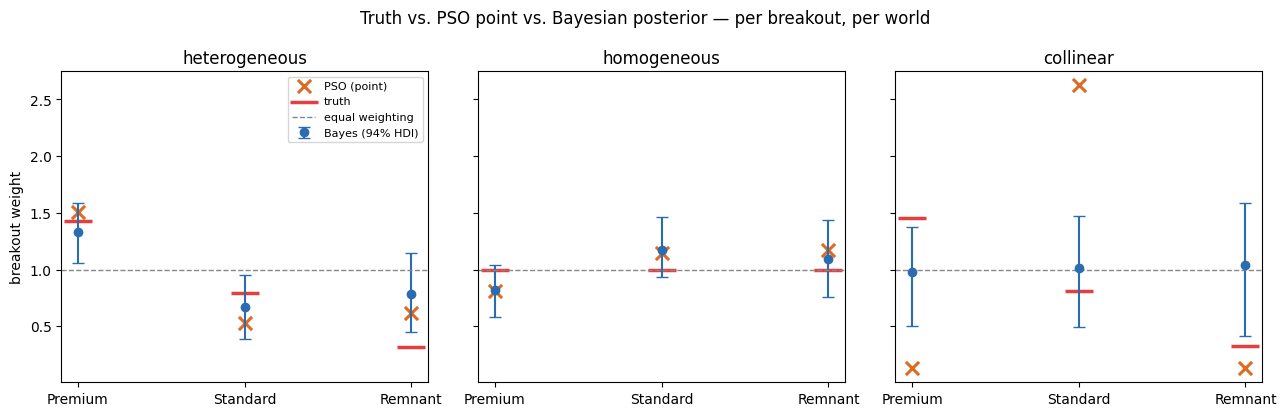

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
order = _SUBS
for ax, name in zip(axes, SCENARIOS):
    brk, _, sc = fits[name]
    df = brk.breakout_weights_summary().set_index("breakout").loc[order]
    truth_w = [sc.notes["true_weights"][s] for s in order]
    pso_w = PSO_WEIGHTS[name]                         # the PSO point (full-data, from §2)
    xpos = np.arange(len(order))
    ax.errorbar(xpos, df["weight_mean"],
                yerr=[df["weight_mean"]-df["hdi_low"], df["hdi_high"]-df["weight_mean"]],
                fmt="o", color="#2b6cb0", capsize=4, label="Bayes (94% HDI)")
    ax.scatter(xpos, pso_w, marker="x", s=90, color="#dd6b20", lw=2.2, label="PSO (point)")
    ax.scatter(xpos, truth_w, marker="_", s=420, color="#e53e3e", lw=2.5, label="truth")
    ax.axhline(1.0, ls="--", lw=1, color="#888", label="equal weighting")
    ax.set_xticks(xpos); ax.set_xticklabels([s.split("_")[1] for s in order])
    ax.set_title(name.replace("breakout_", ""))
axes[0].set_ylabel("breakout weight"); axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Truth vs. PSO point vs. Bayesian posterior — per breakout, per world")
plt.tight_layout(); plt.show()

het = fits["breakout_heterogeneous"][0].breakout_weights_summary().set_index("breakout")
homo = fits["breakout_homogeneous"][0].breakout_weights_summary().set_index("breakout")
col = fits["breakout_collinear"][0].breakout_weights_summary().set_index("breakout")

# heterogeneous: Premium is detected ABOVE equal-weighting (its interval excludes 1)
assert not bool(het.loc["TV_Premium", "covers_equal"])
# homogeneous: every weight's interval COVERS 1 (collapsed to equal-weighting)
assert bool(homo["covers_equal"].all())
# collinear: posteriors are much WIDER than the identifiable fit (honest uncertainty)
het_w = float((het["hdi_high"]-het["hdi_low"]).mean())
col_w = float((col["hdi_high"]-col["hdi_low"]).mean())
assert col_w > 1.3*het_w

The same comparison as an explicit table — **truth, PSO point, and Bayesian
posterior** side by side for every breakout in every world:

In [8]:
cmp_rows = []
for name in SCENARIOS:
    brk, _, sc = fits[name]
    df = brk.breakout_weights_summary().set_index("breakout")
    pso_w = PSO_WEIGHTS[name]
    for i, s in enumerate(_SUBS):
        cmp_rows.append({
            "world": name.replace("breakout_", ""),
            "breakout": s.split("_")[1],
            "truth": round(sc.notes["true_weights"][s], 2),
            "PSO": round(float(pso_w[i]), 2),
            "Bayes mean": round(float(df.loc[s, "weight_mean"]), 2),
            "Bayes 94% HDI": f"[{df.loc[s,'hdi_low']:.2f}, {df.loc[s,'hdi_high']:.2f}]",
            "Bayes covers 1": bool(df.loc[s, "covers_equal"]),
        })
compare = pd.DataFrame(cmp_rows).set_index(["world", "breakout"])
display(compare)

# Where the data does NOT support strong separation (homogeneous truth = 1, and
# the unidentifiable collinear world), the PSO point swings FURTHER from
# equal-weighting than the regularized Bayesian posterior mean does — the PSO
# chases noise, the Bayesian model shrinks. (On collinear the PSO point is wild.)
def _dev(weights):  # max deviation from equal-weighting
    return float(np.max(np.abs(np.asarray(weights) - 1.0)))
pso_dev = sum(_dev(PSO_WEIGHTS[w]) for w in ["breakout_homogeneous", "breakout_collinear"])
bayes_dev = sum(
    _dev(fits[w][0].breakout_weights_summary().set_index("breakout").loc[_SUBS, "weight_mean"])
    for w in ["breakout_homogeneous", "breakout_collinear"]
)
print(f"total deviation from equal-weighting  —  PSO: {pso_dev:.2f}   Bayes: {bayes_dev:.2f}")
assert pso_dev > 1.5 * bayes_dev

truth   PSO  Bayes mean Bayes 94% HDI  Bayes covers 1
world         breakout                                                       
heterogeneous Premium    1.43  1.51        1.33  [1.06, 1.58]           False
              Standard   0.79  0.53        0.67  [0.39, 0.95]           False
              Remnant    0.32  0.61        0.79  [0.45, 1.14]            True
homogeneous   Premium    1.00  0.81        0.82  [0.58, 1.04]            True
              Standard   1.00  1.14        1.18  [0.93, 1.46]            True
              Remnant    1.00  1.17        1.10  [0.76, 1.44]            True
collinear     Premium    1.45  0.13        0.97  [0.50, 1.37]            True
              Standard   0.81  2.62        1.01  [0.49, 1.47]            True
              Remnant    0.32  0.13        1.04  [0.41, 1.58]            True

total deviation from equal-weighting  —  PSO: 1.81   Bayes: 0.22


Three behaviours from one model, no hand-tuning:

* **`heterogeneous`** — the intervals are tight and the strongest breakout
  (Premium) is detected *above* equal-weighting (its HDI excludes the dashed
  line). The signal is real and identifiable, and the model finds it.
* **`homogeneous`** — every interval *covers* equal-weighting. The model has
  **collapsed to the nested null** — where the PSO invented an unequal mix
  (§2), the regularized model correctly says "these are the same."
* **`collinear`** — the planted truth is the *same* as `heterogeneous`, but
  because the sub-streams move together the intervals blow up and cover
  equal-weighting. The model is **honestly uncertain**, not confidently wrong.

Now look at the **orange ×** in the plot and the `PSO` column of the table. On
`heterogeneous` the PSO point lands near truth too — the signal is strong enough
that a point estimate gets lucky. But on `homogeneous` it sits *off* the
equal-weighting line (it fit noise into a mix), and on `collinear` it is **wild**
(e.g. one breakout near zero, another near 2.6) — a confident, precise-looking
answer that is pure noise, with no interval to warn you. The Bayesian posterior
stays near 1 there, and says so. That gap — summed deviation from
equal-weighting, printed above — is the whole point.

The spread parameter $\tau$ is the one-number summary of this behaviour:

In [9]:
tau = pd.DataFrame({
    "logtau_mean (recovered spread)": {
        name.replace("breakout_", ""):
            float(fits[name][0]._trace.posterior["breakout_logtau_TV"].mean())
        for name in SCENARIOS},
    "true_logtau": {
        name.replace("breakout_", ""): dgp.build(name).notes["true_logtau"]
        for name in SCENARIOS},
})
display(tau.round(3))

# τ is the falsification statistic: the recovered spread is largest where the
# breakouts genuinely differ AND are identifiable.
assert tau.loc["heterogeneous", "logtau_mean (recovered spread)"] > \
       tau.loc["homogeneous", "logtau_mean (recovered spread)"]

,logtau_mean (recovered spread),true_logtau
heterogeneous,0.381,0.619
homogeneous,0.260,0.000
collinear,0.246,0.619


## 6 · Does the extra flexibility pay off? (LOO)

The principled way to ask "is the breakout model *better* than just equal-
weighting?" is expected out-of-sample predictive accuracy. We compare each fitted
breakout model to its equal-weight twin by **LOO** (`arviz.loo`): a positive
$\Delta\text{elpd}$ means the breakout model predicts held-out data better.

In [10]:
rows = []
for name in SCENARIOS:
    brk, eq, _ = fits[name]
    d = float(_loo(brk).elpd_loo - _loo(eq).elpd_loo)
    rows.append({"world": name.replace("breakout_", ""), "Δelpd (breakout − equal)": round(d, 1),
                 "verdict": "breakout helps" if d > 2 else "~tie (no gain)"})
loo = pd.DataFrame(rows).set_index("world")
display(loo)

# The flexibility pays off ONLY where the signal is real and identifiable.
assert loo.loc["heterogeneous", "Δelpd (breakout − equal)"] > \
       loo.loc["homogeneous", "Δelpd (breakout − equal)"]
assert loo.loc["heterogeneous", "Δelpd (breakout − equal)"] > \
       loo.loc["collinear", "Δelpd (breakout − equal)"]

,Δelpd (breakout − equal),verdict
world,,
heterogeneous,5.5,breakout helps
homogeneous,0.2,~tie (no gain)
collinear,0.3,~tie (no gain)


$\Delta\text{elpd}\approx 0$ on `homogeneous` and `collinear`: the extra weight
parameters buy **no** out-of-sample accuracy there — the model has correctly
declined to use them. On `heterogeneous`, the breakout model genuinely predicts
better. This is the difference the PSO's in-sample MSE can never show you: it
*always* improves in-sample, whether or not there is anything to learn.

## 7 · The identifiability ceiling (pre-fit)

Why is the model *right* to be uncertain on `collinear`? Because no method can
separate weights the data can't distinguish. A pre-fit collinearity check on the
sub-stream impressions shows the ceiling before a single posterior draw.

In [11]:
from mmm_framework.eda.collinearity import collinearity_analysis
from mmm_framework.eda.loading import load_eda_panel_from_df

rows = []
for name in ["breakout_heterogeneous", "breakout_collinear"]:
    sc = dgp.build(name)
    wide = pd.DataFrame({"Period": sc.weeks})
    for s in _SUBS:
        wide[s] = sc.spend[s].to_numpy()
    panel = load_eda_panel_from_df(wide, {"media_channels": [{"name": s} for s in _SUBS]})
    res = collinearity_analysis(panel, variables=_SUBS)
    rows.append({
        "world": name.replace("breakout_", ""),
        "mean |r|": round(np.mean([abs(p["r"]) for p in res["top_pairs"]]), 2),
        "max VIF": round(max(res["vif"].values()), 1),
        "condition #": round(res["condition_number"], 1),
        "collinear clusters": len(res["clusters"]),
    })
collin = pd.DataFrame(rows).set_index("world")
display(collin)

# The collinear world's sub-streams are nearly inseparable (huge VIF / condition
# number); the heterogeneous world's are not. The wide posteriors in §5 are
# correct, not a bug.
assert collin.loc["collinear", "max VIF"] > 10 * collin.loc["heterogeneous", "max VIF"]

,mean |r|,max VIF,condition #,collinear clusters
world,,,,
heterogeneous,0.03,1.0,1.1,0
collinear,1.00,298.4,1340.0,1


## What to remember

| | PSO optimizer | `BreakoutWeightedMMM` |
|---|---|---|
| objective | in-sample MSE | joint posterior (regularized) |
| weights | point estimate | partial-pooled, with credible intervals |
| equal-truth world | invents an unequal mix (§2) | collapses to equal-weighting (§5) |
| unidentifiable world | confident, noise-driven point | honestly wide posteriors (§5) |
| "is it really different?" | unanswerable | read the interval / $\tau$ |
| out-of-sample | gain evaporates (§3) | helps only when real (§6) |

1. **In-sample MSE always drops** with $K-1$ free weights × a nonlinear curve —
   that is mechanical, not signal. Judge by held-out accuracy (or LOO), and
   against the equal-weight null.
2. **Regularize the weights and estimate the spread $\tau$.** The model then
   *learns* whether a granular signal exists: $\tau\to0$ nests the equal-weight
   model; $\tau>0$ moves the weights — with intervals.
3. **Intervals are the product.** "This breakout is more effective" is a claim
   that needs a credible interval excluding equal-weighting; the PSO can't give
   one.
4. **The real prerequisite is independent variation in exposure** (distinct
   flighting; breakout-level experiments / geo holdouts). When sub-streams move
   together, *no* optimizer can separate them — the honest model says so, the
   PSO does not.

> Run the same comparison from the command line:
> `uv run python examples/garden_models/breakout_pso_vs_bayes.py`
> (add `--fast` to skip the MCMC). Tests:
> `uv run pytest tests/test_breakout_weighted_mmm.py`.